In [11]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# for the tensorpac function
import urllib
from scipy.io import loadmat
from tensorpac import Pac, EventRelatedPac, PreferredPhase
from tensorpac.utils import PeakLockedTF, PSD, ITC, BinAmplitude

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

%matplotlib inline
%load_ext autoreload
%autoreload 2

C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\PAC\Python3_icsd.py:892: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if f_type is not 'identity' and f_order is None:


In [12]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1, rc={"lines.linewidth": 2, "axes.linewidth":2, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 5, "ytick.major.size": 5})

rc_pub={'font.size': 15, 'axes.labelsize': 15, 'legend.fontsize': 15, 
    'axes.titlesize': 15, 'xtick.labelsize': 15, 'ytick.labelsize': 15, 
    'axes.linewidth':2, 'lines.linewidth': 2,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

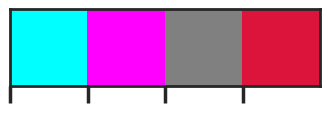

In [13]:
pal=sns.blend_palette(['cyan','magenta','grey','crimson'],4)
sns.palplot(pal)
sns.set_palette(pal)

---

# Load some necessary variables

In [14]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [15]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

# Load previous saved PAC arrays

In [16]:
rew_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_rew.npy")
rew_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_rew.npy")

rew2_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_rew2.npy")
rew2_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_rew2.npy")

unrew_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_unrew.npy")
unrew_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_unrew.npy")

novel_wt = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\wt_novel.npy")
novel_fx = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\PAC\fx_novel.npy")

In [17]:
print('Rewarded with water arrays (wt & fx)')
print(rew_wt.shape)
print(rew_fx.shape)
print('Rewarded without water arrays (wt & fx)')
print(rew2_wt.shape)
print(rew2_fx.shape)
print('Unrewarded arrays (wt & fx)')
print(unrew_wt.shape)
print(unrew_fx.shape)
print('Novel arrays (wt & fx)')
print(novel_wt.shape)
print(novel_fx.shape)

Rewarded with water arrays (wt & fx)
(10, 80, 7350)
(8, 80, 7350)
Rewarded without water arrays (wt & fx)
(10, 20, 7350)
(8, 20, 7350)
Unrewarded arrays (wt & fx)
(10, 50, 7350)
(8, 50, 7350)
Novel arrays (wt & fx)
(10, 49, 7350)
(6, 49, 7350)


---

# PAC analysis for all mice in each group
- TensorPAC documentation here: https://etiennecmb.github.io/tensorpac/api.html#utility-functions

In [18]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sf = 2500                                             # sampling frequency
times = np.linspace(0, samples_tr/sf, samples_tr)     # time vector

In [19]:
def PAC_group_analysis(mouse_array, p_obj, t_arr, sf=2500, times=np.linspace(0, samples_tr/sf, samples_tr)):
    # extract all of the phases and amplitudes
    pha_p = p_obj.filter(sf, mouse_array, ftype='phase')
    amp_p = p_obj.filter(sf, mouse_array, ftype='amplitude')
    # define time indices where oscillations
    t1 = int(t_arr[0]*2500)
    t2 = int(t_arr[1]*2500)
    time_2 = slice(t1, t2)
    # define phase / amplitude during oscillation
    pha_2, amp_2 = pha_p[..., time_2], amp_p[..., time_2]
    # compute PAC inside oscillation
    pac_2 = p_obj.fit(pha_2, amp_2).mean(-1)
    return pac_2

def group_avg_PAC(group_array, p_obj, t_arr):
    all_pac_2 = []
    #loop through individual mice to create PAC array with "PAC_group_analysis" function above
    for mouse in range(group_array.shape[0]):
        print('Mouse {}'.format(mouse))
        foo_arr = group_array[mouse]
        try:
            pac_2 = PAC_group_analysis(foo_arr, p_obj, t_arr)
            #append individual mice to group list
            all_pac_2.append(pac_2)
        except:
            print('Problem with mouse {}'.format(mouse))
    #convert lists to numpy.arrays    
    all_pac_2=np.array(all_pac_2)
    return all_pac_2

## Explanation for the below p_obj
Here are the various methods of calculating the values (relates to idpac=(x,0,0) variable)
1. Mean Vector Length (MVL)
2. Modulation Index (MI)
3. Heights Ratio (HR)
4. ndPAC
5. Phase-Locking value (PLV)
6. Gaussian Copula PAC (GCPAC)

In [155]:


# p_obj = Pac(idpac=(6, 0, 0), f_pha=(4, 8, 0.5, .1), f_amp=(30, 70, 2, 1)) #(start, stop, width, step)
p_obj = Pac(idpac=(6, 0, 0), f_pha=(3, 9, 0.5, .1), f_amp=(30, 80, 2, 1)) #(start, stop, width, step)

tim_arr = [0.5,1.2]
tim_arr_sp = [2.2,2.6]



Phase Amplitude Coupling object defined


In [156]:
# rewarded with water situation
all_rew_wt = group_avg_PAC(rew_wt, p_obj, t_arr=tim_arr)
all_rew_fx = group_avg_PAC(rew_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_rew_wt = np.mean(all_rew_wt, axis=0)
mid_rew_fx = np.mean(all_rew_fx, axis=0)

# rewarded without water situation
all_rew2_wt = group_avg_PAC(rew2_wt, p_obj, t_arr=tim_arr)
all_rew2_fx = group_avg_PAC(rew2_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_rew2_wt = np.mean(all_rew2_wt, axis=0)
mid_rew2_fx = np.mean(all_rew2_fx, axis=0)

# unrewarded situation
all_unrew_wt = group_avg_PAC(unrew_wt, p_obj, t_arr=tim_arr)
all_unrew_fx = group_avg_PAC(unrew_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_unrew_wt = np.mean(all_unrew_wt, axis=0)
mid_unrew_fx = np.mean(all_unrew_fx, axis=0)

# novel situation
all_novel_wt = group_avg_PAC(novel_wt, p_obj, t_arr=tim_arr)
all_novel_fx = group_avg_PAC(novel_fx, p_obj, t_arr=tim_arr)
#average the numpy.arrays across all mice in the group
mid_novel_wt = np.mean(all_novel_wt, axis=0)
mid_novel_fx = np.mean(all_novel_fx, axis=0)

Mouse 0


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 1


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 2


...

    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 4


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 5


    true PAC estimation using Gaussian Copula PAC (gcPac)


## PAC of spontaneous background noise

In [157]:
# rewarded with water situation
sp_all_rew_wt = group_avg_PAC(rew_wt, p_obj, t_arr=tim_arr_sp)
sp_all_rew_fx = group_avg_PAC(rew_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_rew_wt = np.mean(sp_all_rew_wt, axis=0)
sp_mid_rew_fx = np.mean(sp_all_rew_fx, axis=0)

# rewarded without water situation
sp_all_rew2_wt = group_avg_PAC(rew2_wt, p_obj, t_arr=tim_arr_sp)
sp_all_rew2_fx = group_avg_PAC(rew2_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_rew2_wt = np.mean(sp_all_rew2_wt, axis=0)
sp_mid_rew2_fx = np.mean(sp_all_rew2_fx, axis=0)

# unrewarded situation
sp_all_unrew_wt = group_avg_PAC(unrew_wt, p_obj, t_arr=tim_arr_sp)
sp_all_unrew_fx = group_avg_PAC(unrew_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_unrew_wt = np.mean(sp_all_unrew_wt, axis=0)
sp_mid_unrew_fx = np.mean(sp_all_unrew_fx, axis=0)

# novel situation
sp_all_novel_wt = group_avg_PAC(novel_wt, p_obj, t_arr=tim_arr_sp)
sp_all_novel_fx = group_avg_PAC(novel_fx, p_obj, t_arr=tim_arr_sp)
#average the numpy.arrays across all mice in the group
sp_mid_novel_wt = np.mean(sp_all_novel_wt, axis=0)
sp_mid_novel_fx = np.mean(sp_all_novel_fx, axis=0)

Mouse 0


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 1


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 2


...

    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 4


    true PAC estimation using Gaussian Copula PAC (gcPac)


Mouse 5


    true PAC estimation using Gaussian Copula PAC (gcPac)


In [158]:
#subtract the oscillation PAC with the spontaneous PAC
mid2_rew_wt = abs(mid_rew_wt - sp_mid_rew_wt)
mid2_rew2_wt = abs(mid_rew2_wt - sp_mid_rew2_wt)
mid2_unrew_wt = abs(mid_unrew_wt - sp_mid_unrew_wt)
mid2_novel_wt = abs(mid_novel_wt - sp_mid_novel_wt)

mid2_rew_fx = abs(mid_rew_fx - sp_mid_rew_fx)
mid2_rew2_fx = abs(mid_rew2_fx - sp_mid_rew2_fx)
mid2_unrew_fx = abs(mid_unrew_fx - sp_mid_unrew_fx)
mid2_novel_fx = abs(mid_novel_fx - sp_mid_novel_fx)


# Normalize the arrays
There's different ways of normalizing it
1. normalize across each __situation__ against both __groups__ ("norm_situation)
2. normalize across each __group__ against both __situations__ ("norm_group")
3. normalize across all __groups__ and __situations__ ("norm_all")

In [159]:
def norm_situation(wt_array, fx_array):
    max_max = np.max([wt_array.max(), fx_array.max()])
    out_wt = wt_array/max_max
    out_fx = fx_array/max_max
    return out_wt, out_fx

def norm_group(array1, array2, array3, array4):
    max_max = np.max([array1.max(), array2.max(), array3.max(), array4.max()])
    out1 = array1/max_max
    out2 = array2/max_max
    out3 = array3/max_max
    out4 = array4/max_max
    return out1, out2, out3, out4

def norm_all(wtarray1, wtarray2, wtarray3, wtarray4, fxarray1, fxarray2, fxarray3, fxarray4):
    max_max = np.max([wtarray1.max(), wtarray2.max(), wtarray3.max(), wtarray4.max(), 
                      fxarray1.max(), fxarray2.max(), fxarray3.max(), fxarray4.max()])
    wtout1 = wtarray1/max_max
    wtout2 = wtarray2/max_max
    wtout3 = wtarray3/max_max
    wtout4 = wtarray4/max_max
    fxout1 = fxarray1/max_max
    fxout2 = fxarray2/max_max
    fxout3 = fxarray3/max_max
    fxout4 = fxarray4/max_max
    return wtout1, wtout2, wtout3, wtout4, fxout1, fxout2, fxout3, fxout4

#### Normal PAC
Run either this cell or the cell below!

In [160]:
## Normalize the situation across groups
# norm_rew_wt, norm_rew_fx = norm_situation(mid_rew_wt, mid_rew_fx)
# norm_rew2_wt, norm_rew2_fx = norm_situation(mid_rew2_wt, mid_rew2_fx)
# norm_unrew_wt, norm_unrew_fx = norm_situation(mid_unrew_wt, mid_unrew_fx)
# norm_novel_wt, norm_novel_fx = norm_situation(mid_novel_wt, mid_novel_fx)

## Normalize the group across situations
norm_rew_wt, norm_rew2_wt, norm_unrew_wt, norm_novel_wt = norm_group(mid_rew_wt, mid_rew2_wt, mid_unrew_wt, mid_novel_wt)
norm_rew_fx, norm_rew2_fx, norm_unrew_fx, norm_novel_fx = norm_group(mid_rew_fx, mid_rew2_fx, mid_unrew_fx, mid_novel_fx)

## Normalize everything together
# norm_rew_wt, norm_rew2_wt, norm_unrew_wt, norm_novel_wt, norm_rew_fx, norm_rew2_fx, norm_unrew_fx, norm_novel_fx = norm_all(mid_rew_wt, mid_rew2_wt, mid_unrew_wt, mid_novel_wt, 
#                                                                                                                             mid_rew_fx, mid_rew2_fx, mid_unrew_fx, mid_novel_fx)



#### Spontaneous activity removed PAC

In [171]:
## Normalize the situation across groups
# norm_rew_wt, norm_rew_fx = norm_situation(mid2_rew_wt, mid2_rew_fx)
# norm_rew2_wt, norm_rew2_fx = norm_situation(mid2_rew2_wt, mid2_rew2_fx)
# norm_unrew_wt, norm_unrew_fx = norm_situation(mid2_unrew_wt, mid2_unrew_fx)
# norm_novel_wt, norm_novel_fx = norm_situation(mid2_novel_wt, mid2_novel_fx)

## Normalize the group across situations
norm_rew_wt, norm_rew2_wt, norm_unrew_wt, norm_novel_wt = norm_group(mid2_rew_wt, mid2_rew2_wt, mid2_unrew_wt, mid2_novel_wt)
norm_rew_fx, norm_rew2_fx, norm_unrew_fx, norm_novel_fx = norm_group(mid2_rew_fx, mid2_rew2_fx, mid2_unrew_fx, mid2_novel_fx)

# Compute the difference between WT & FX

In [172]:
plot_input = 'norm'

if plot_input == 'raw':
    # rew_diff = mid_rew_wt - mid_rew_fx
    # rew2_diff = mid_rew2_wt - mid_rew2_fx
    # unrew_diff = mid_unrew_wt - mid_unrew_fx
    # novel_diff = mid_novel_wt - mid_novel_fx
    rew_diff = mid2_rew_wt - mid2_rew_fx
    rew2_diff = mid2_rew2_wt - mid2_rew2_fx
    unrew_diff = mid2_unrew_wt - mid2_unrew_fx
    novel_diff = mid2_novel_wt - mid2_novel_fx
    rew_diff, rew2_diff, unrew_diff, novel_diff = norm_situation(rew_diff, rew2_diff, unrew_diff, novel_diff)
elif plot_input == 'norm':
    rew_diff = norm_rew_wt - norm_rew_fx
    rew2_diff = norm_rew2_wt - norm_rew2_fx
    unrew_diff = norm_unrew_wt - norm_unrew_fx
    novel_diff = norm_novel_wt - norm_novel_fx
    
print(rew_diff.shape)
print(rew2_diff.shape)
print(unrew_diff.shape)
print(novel_diff.shape)

(48, 55)
(48, 55)
(48, 55)
(48, 55)


## Plot PAC to compare WT/FX

In [173]:
if plot_input == 'raw':
    vmin, vmax = 0.0, 0.3
    vmin1, vmax1 = 0.0, 1.0
    kw = dict(vmax=vmax, vmin=vmin, cmap='viridis')
    kw00 = dict(vmax=vmax1, vmin=vmin1, cmap='plasma')
    cb_dif = vmax1-vmin1
    cbar_ticks = [(vmin1),(cb_dif/2+vmin1),vmax1]
elif plot_input == 'norm':
    vmin, vmax = 0.0, 0.8
    vmin1, vmax1 = 0.1, 0.4
    kw = dict(vmax=vmax, vmin=vmin, cmap='viridis')
    kw00 = dict(vmax=vmax1, vmin=vmin1, cmap='plasma')
    cb_dif = vmax1-vmin1
    cbar_ticks = [(vmin1),(cb_dif/2+vmin1),vmax1]
    

In [174]:
if plot_input == 'raw':
    rew1, rew2, rew3 = mid_rew_wt, mid_rew_fx, rew_diff
    rew21, rew22, rew23 = mid_rew2_wt, mid_rew2_fx, rew2_diff
    unrew1, unrew2, unrew3 = mid_unrew_wt, mid_unrew_fx, unrew_diff
    novel1, novel2, novel3 = mid_novel_wt, mid_novel_fx, novel_diff
elif plot_input == 'norm':
    rew1, rew2, rew3 = norm_rew_wt, norm_rew_fx, rew_diff
    rew21, rew22, rew23 = norm_rew2_wt, norm_rew2_fx, rew2_diff
    unrew1, unrew2, unrew3 = norm_unrew_wt, norm_unrew_fx, unrew_diff
    novel1, novel2, novel3 = norm_novel_wt, norm_novel_fx, novel_diff

### Rewarded with Water

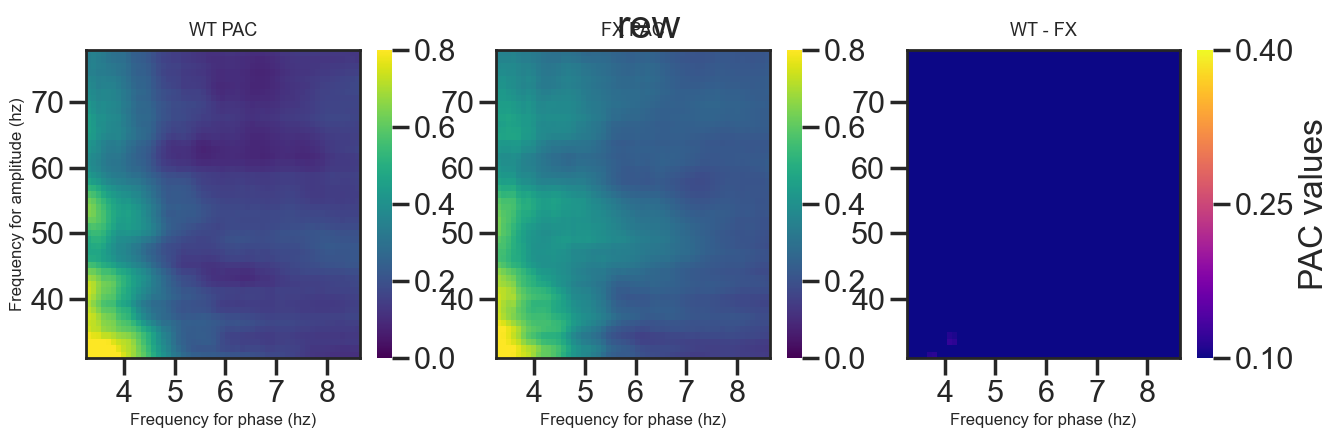

In [175]:
plt.figure(figsize=(15, 4))
plt.suptitle("rew")
ax1=plt.subplot(131)
p_obj.comodulogram(rew1, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew2, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew3, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
cbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\rew_PACMI_heat.pdf", transparent=True)

plt.show()

### Rewarded without Water

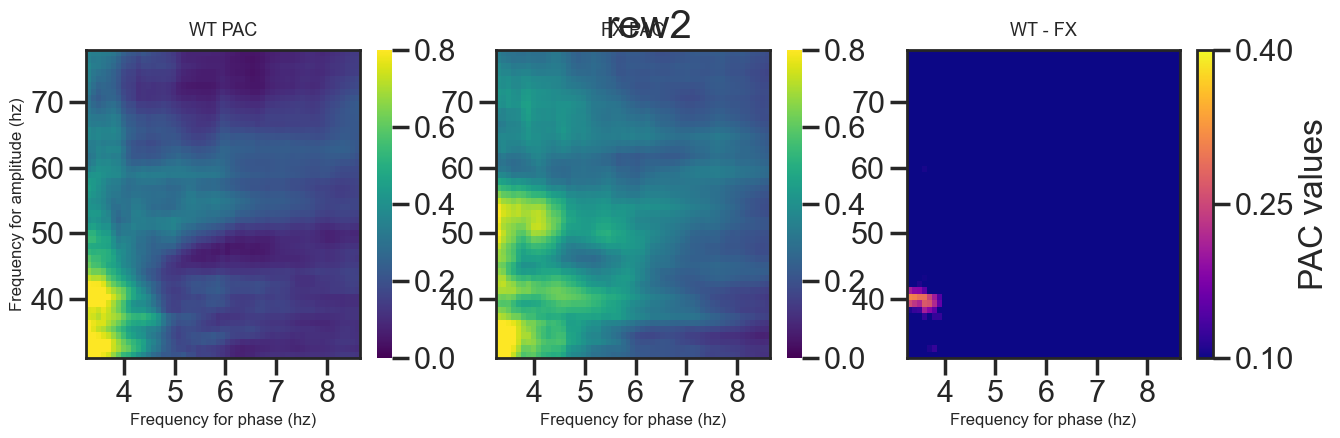

In [176]:
plt.figure(figsize=(15, 4))
plt.suptitle("rew2")
ax1=plt.subplot(131)
p_obj.comodulogram(rew21, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew22, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(rew23, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
### Rewarded with Watercbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\rew2_PACMI_heat.pdf", transparent=True)

plt.show()

### Unrewarded

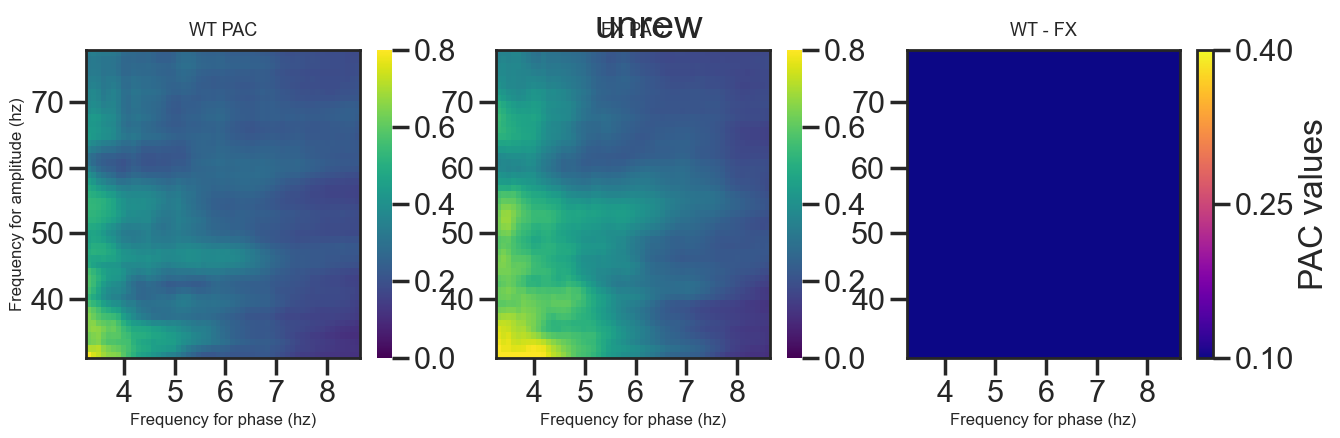

In [177]:
plt.figure(figsize=(15, 4))
plt.suptitle("unrew")
ax1=plt.subplot(131)
p_obj.comodulogram(unrew1, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(unrew2, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(unrew3, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
### Rewarded with Watercbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\unrew_PACMI_heat.pdf", transparent=True)

plt.show()

### Novel

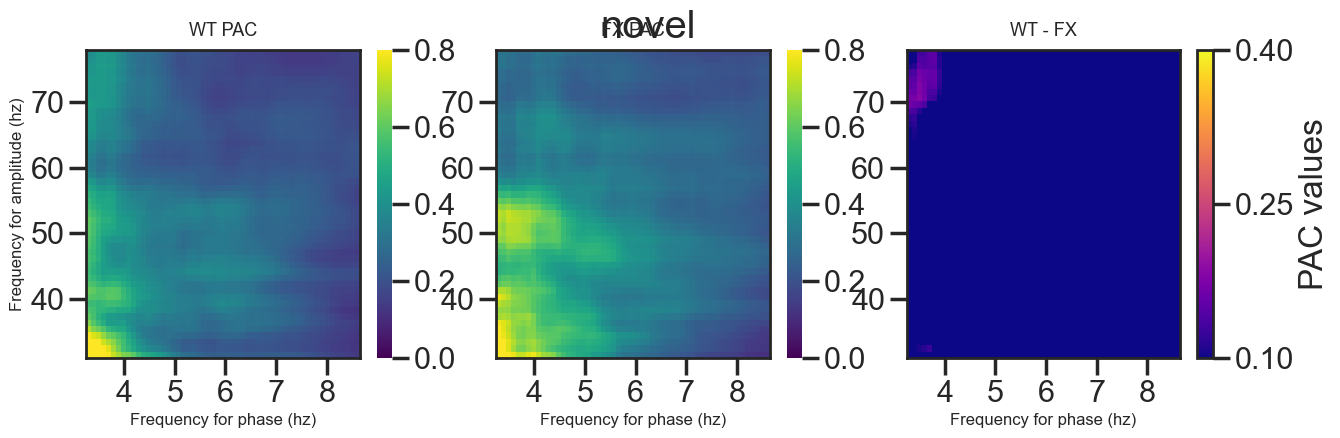

In [178]:
plt.figure(figsize=(15, 4))
plt.suptitle("novel")
ax1=plt.subplot(131)
p_obj.comodulogram(novel1, title="WT PAC", colorbar=False, **kw)
plt.xticks([3,4,5,6,7,8,9])
plt.yticks([30,40,50,60,70,80])
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax2=plt.subplot(132, sharex=ax1, sharey=ax1)
p_obj.comodulogram(novel2, title="FX PAC", colorbar=False, **kw)
plt.ylabel('')
cbar=plt.colorbar()
cbar.set_ticks([vmin,(vmax/4),(vmax/2),(vmax/2+vmax/4),vmax])
cbar.outline.set_visible(False)

ax3=plt.subplot(133, sharex=ax1, sharey=ax1)
p_obj.comodulogram(novel3, title="WT - FX", colorbar=False, **kw00)
plt.ylabel('')
cbar=plt.colorbar(label='PAC values')
cbar.set_ticks(cbar_ticks)
### Rewarded with Watercbar.outline.set_visible(False)

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\novel_PACMI_heat.pdf", transparent=True)

plt.show()

---

# Quantify the PAC analysis plots above
Essentially I take the mean PAC for each of the regions of interest (Theta:Gamma, Theta:LowGamma, Theta:HighGamma). My manually counted indices based on the PAC object for p_obj
- tlg = matrix[7:27,2:12].mean()
- thg = matrix[7:27,13:27].mean()
- tg = matrix[7:27,2:27].mean()

And for p_obj = Pac(idpac=(6, 0, 0), f_pha=(3, 9, 0.5, .1), f_amp=(30, 80, 2, 1))
- tlg = matrix[7:48,0:20].mean()
- thg = matrix[7:48,21:48].mean()
- tg = matrix[7:48,0:48].mean()

In [179]:
def quantify_pac(all_pac_array):
    theta_low = []
    theta_high = []
    theta_gamma = []
    for mouse, matrix in enumerate(all_pac_array):
        tlg = matrix[7:48,0:20].mean()    #manually counted indices from pac array created by p_obj defined earlier
        thg = matrix[7:48,21:48].mean()
        tg = matrix[7:48,0:48].mean()
        theta_low.append(tlg)
        theta_high.append(thg)
        theta_gamma.append(tg)
    tlg_df = pd.DataFrame(zip(theta_low,['T:LG']*len(theta_low)), columns=['pac_val','coupling'])
    thg_df = pd.DataFrame(zip(theta_high,['T:HG']*len(theta_high)), columns=['pac_val','coupling'])
    tg_df = pd.DataFrame(zip(theta_gamma,['T:G']*len(theta_gamma)), columns=['pac_val','coupling'])
    combo_df = pd.concat([tlg_df, thg_df, tg_df])
    return combo_df


def quantify_pac_help(wt_array, fx_array, situation):
    df_wt = quantify_pac(wt_array)
    df_wt['group']='wt'
    df_fx = quantify_pac(fx_array)
    df_fx['group']='fx'
    df_pac = pd.concat([df_wt, df_fx])
    df_pac['situ']=situation
    return df_pac

def remove_spontaneous(wt_osc_array, wt_sp_array, fx_osc_array, fx_sp_array, situation):
    wt_array = wt_osc_array - wt_sp_array
    fx_array = fx_osc_array - fx_sp_array
    df_pac = quantify_pac_help(wt_array, fx_array, situation)
    return df_pac

In [180]:
rew_pac = quantify_pac_help(all_rew_wt, all_rew_fx, 'rew')
rew2_pac = quantify_pac_help(all_rew2_wt, all_rew2_fx, 'rew2')
unrew_pac = quantify_pac_help(all_unrew_wt, all_unrew_fx, 'unrew')
novel_pac = quantify_pac_help(all_novel_wt, all_novel_fx, 'novel')

# rew_pac = remove_spontaneous(all_rew_wt, sp_all_rew_wt, all_rew_fx, sp_all_rew_fx, 'rew')
# rew2_pac = remove_spontaneous(all_rew2_wt, sp_all_rew2_wt, all_rew2_fx, sp_all_rew2_fx, 'rew2')
# unrew_pac = remove_spontaneous(all_unrew_wt, sp_all_unrew_wt, all_unrew_fx, sp_all_unrew_fx, 'unrew')
# novel_pac = remove_spontaneous(all_novel_wt, sp_all_novel_wt, all_novel_fx, sp_all_novel_fx, 'novel')

big_pac_df = pd.concat([rew_pac, rew2_pac, unrew_pac, novel_pac])

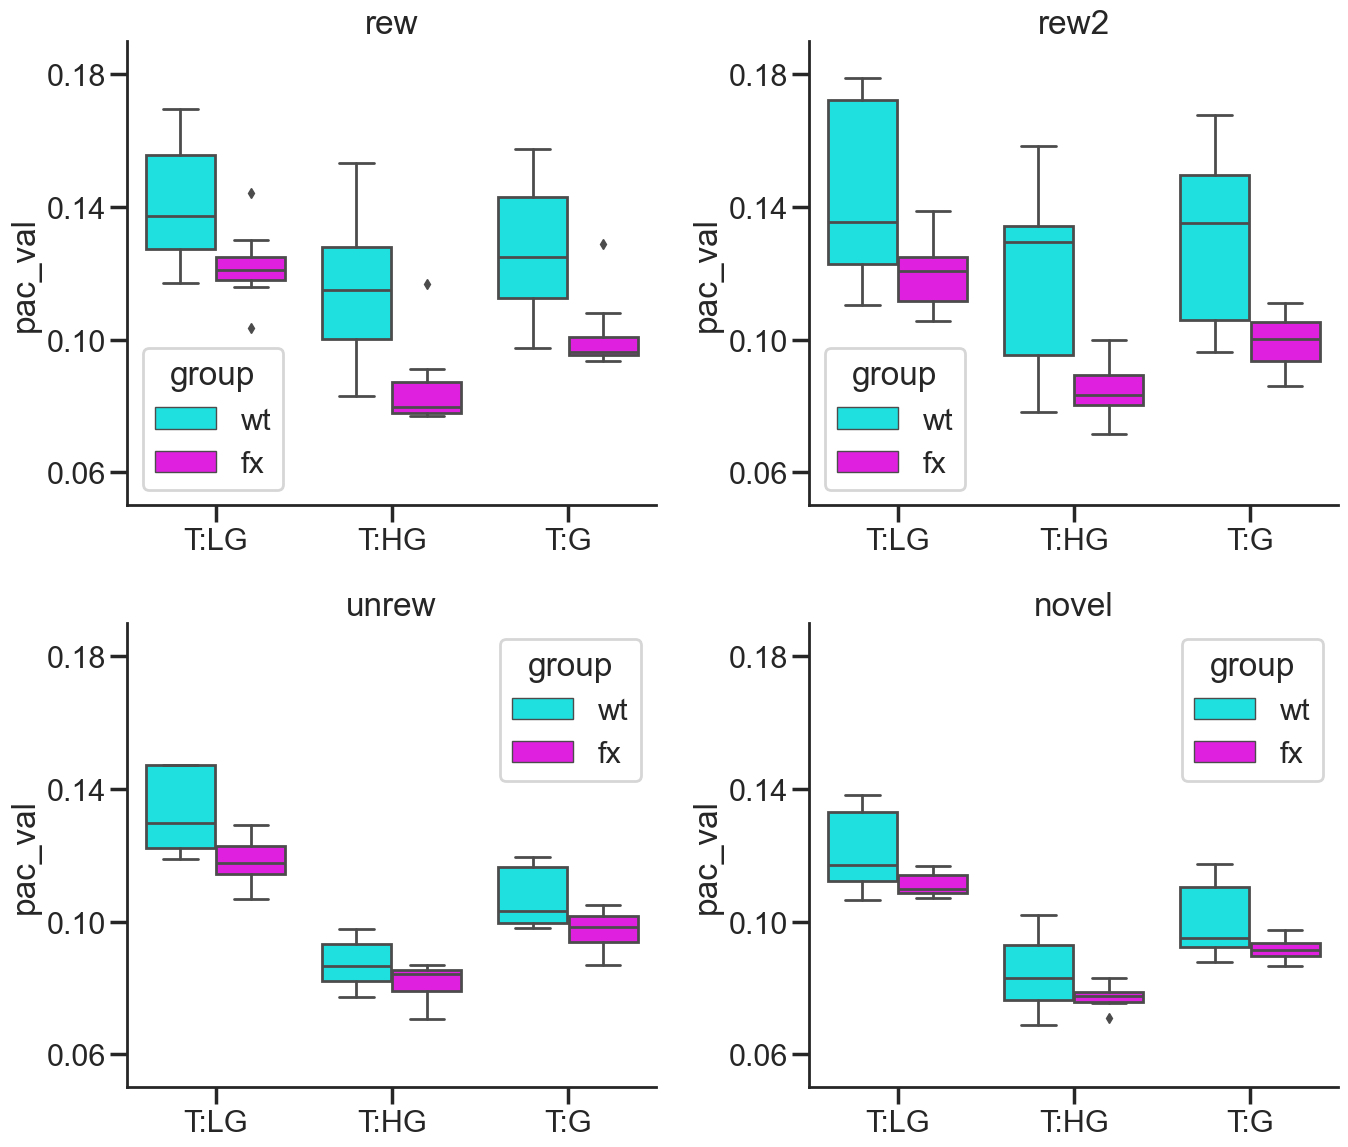

In [184]:
plt.figure(figsize=(14, 12))
ax1=plt.subplot(221)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=rew_pac)
plt.title('rew')
plt.ylim([0.05, 0.19])
plt.yticks([0.06, 0.10, 0.14, 0.18])
plt.xlabel('')
ax2=plt.subplot(222, sharey=ax1)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=rew2_pac)
plt.title('rew2')
plt.xlabel('')
ax3=plt.subplot(223, sharey=ax1)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=unrew_pac)
plt.title('unrew')
plt.xlabel('')
ax4=plt.subplot(224, sharey=ax1)
sns.boxplot(x="coupling", y="pac_val", hue='group', data=novel_pac)
plt.title('novel')
plt.xlabel('')

sns.despine()
plt.tight_layout()
# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Papers\FX Behavior paper\quantified_pac.pdf", transparent=True)

plt.show()

In [164]:
def pac_stats(situation_df, situation):
    data1 = situation_df[situation_df['group'] == 'wt']
    data2 = situation_df[situation_df['group'] == 'fx']

    varA1 = data1[data1['coupling']=='T:LG'].pac_val.values
    varA2 = data1[data1['coupling']=='T:HG'].pac_val.values
    varA3 = data1[data1['coupling']=='T:G'].pac_val.values

    varB1 = data2[data2['coupling']=='T:LG'].pac_val.values
    varB2 = data2[data2['coupling']=='T:HG'].pac_val.values
    varB3 = data2[data2['coupling']=='T:G'].pac_val.values

    print('Pac stats --- {0} ---'.format(situation))
    print('tlg: {0}'.format(sstat.mannwhitneyu(varA1, varB1)))
    print('thg: {0}'.format(sstat.mannwhitneyu(varA2, varB2)))
    print('tg: {0}'.format(sstat.mannwhitneyu(varA3, varB3)))    
    print('{0} wt & {1} fx mice'.format(len(varA1),len(varB1)))
    print('{0} wt & {1} fx mice'.format(len(varA2),len(varB2)))
    print('{0} wt & {1} fx mice'.format(len(varA3),len(varB3)))
    return

In [166]:
pac_stats(rew_pac, 'rew')
pac_stats(rew2_pac, 'rew2')
pac_stats(unrew_pac, 'unrew')
pac_stats(novel_pac, 'novel')

Pac stats --- rew ---
tlg: MannwhitneyuResult(statistic=64.0, pvalue=0.03660091820858935)
thg: MannwhitneyuResult(statistic=70.0, pvalue=0.008694130557126317)
tg: MannwhitneyuResult(statistic=68.0, pvalue=0.014446516817694632)
10 wt & 8 fx mice
10 wt & 8 fx mice
10 wt & 8 fx mice
Pac stats --- rew2 ---
tlg: MannwhitneyuResult(statistic=65.0, pvalue=0.029321853737353406)
thg: MannwhitneyuResult(statistic=67.0, pvalue=0.018422231260785786)
tg: MannwhitneyuResult(statistic=67.0, pvalue=0.018422231260785786)
10 wt & 8 fx mice
10 wt & 8 fx mice
10 wt & 8 fx mice
Pac stats --- unrew ---
tlg: MannwhitneyuResult(statistic=59.0, pvalue=0.09987351755271681)
thg: MannwhitneyuResult(statistic=66.0, pvalue=0.02332455645326239)
tg: MannwhitneyuResult(statistic=64.0, pvalue=0.03660091820858935)
10 wt & 8 fx mice
10 wt & 8 fx mice
10 wt & 8 fx mice
Pac stats --- novel ---
tlg: MannwhitneyuResult(statistic=54.0, pvalue=0.010689471247729808)
thg: MannwhitneyuResult(statistic=38.0, pvalue=0.4152508267059

---

---

---

---

---

# Identify the preferred phase

In [11]:
def group_pref_phase(mouse_array, sf=2500, phase=[4,8]):
    # define the preferred phase object
    pp_obj = PreferredPhase(f_pha=phase)
    # define time indices where rest, planning and execution are defined
    t1 = int(0.5*sf)
    t2 = int(2.0*sf)
    t3 = int(2.9*sf)
    time_1 = slice(0, t1)
    time_2 = slice(t1, t2)
    time_3 = slice(t2, t3)
    # define the PAC object
    p_obj = Pac(idpac=(6, 0, 0), f_pha=(1, 12, 2, .2), f_amp=(25, 85, 10, 2))
    # extract all of the phases and amplitudes
    pha_p = p_obj.filter(sf, mouse_array, ftype='phase')
    amp_p = p_obj.filter(sf, mouse_array, ftype='amplitude')
    # define phase / amplitude during pre / mid / post
    pha_1, amp_1 = pha_p[..., time_1], amp_p[..., time_1]
    pha_2, amp_2 = pha_p[..., time_2], amp_p[..., time_2]
    pha_3, amp_3 = pha_p[..., time_3], amp_p[..., time_3]
    # only extract the theta phase
    pp_pha = pp_obj.filter(sf, mouse_array, ftype='phase')
    pp_pha_1 = pp_pha[..., time_1]
    pp_pha_2 = pp_pha[..., time_2]
    pp_pha_3 = pp_pha[..., time_3]
    # compute the preferred phase (reuse the amplitude computed above)
    ampbin_1, _, vecbin = pp_obj.fit(pp_pha_1, amp_1, n_bins=72)
    ampbin_2, _, vecbin = pp_obj.fit(pp_pha_2, amp_2, n_bins=72)
    ampbin_3, _, vecbin = pp_obj.fit(pp_pha_3, amp_3, n_bins=72)
    # mean binned amplitude across trials
    ampbin_1 = np.squeeze(ampbin_1).mean(-1).T
    ampbin_2 = np.squeeze(ampbin_2).mean(-1).T
    ampbin_3 = np.squeeze(ampbin_3).mean(-1).T
    
    return ampbin_1, ampbin_2, ampbin_3, vecbin, p_obj

In [12]:
def group_avg_pref_phase(group_array):
    all_pp_1 = []
    all_pp_2 = []
    all_pp_3 = []
    #loop through individual mice to create array with "group_pref_phase" function above
    for mouse in range(group_array.shape[0]):
        print('Mouse {}'.format(mouse))
        foo_arr = group_array[mouse]
        pp_1, pp_2, pp_3, vecbin, p_obj = group_pref_phase(foo_arr)
        #append individual mice to group list
        all_pp_1.append(pp_1)
        all_pp_2.append(pp_2)
        all_pp_3.append(pp_3)
    #convert lists to numpy.arrays    
    all_pp_1=np.array(all_pp_1)
    all_pp_2=np.array(all_pp_2)
    all_pp_3=np.array(all_pp_3)
    #average the numpy.arrays across all mice in the group
    avg_pp_1 = np.mean(all_pp_1, axis=0)
    avg_pp_2 = np.mean(all_pp_2, axis=0)
    avg_pp_3 = np.mean(all_pp_3, axis=0)
    
    return avg_pp_1, avg_pp_2, avg_pp_3, vecbin, p_obj

In [13]:
# rewarded with water situation
pp1_rew_wt, pp2_rew_wt, pp3_rew_wt, vb_rew_wt, po_rew_wt = group_avg_pref_phase(rew_wt)
pp1_rew_fx, pp2_rew_fx, pp3_rew_fx, vb_rew_fx, po_rew_fx = group_avg_pref_phase(rew_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 5


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 6


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 7


In [14]:
# rewarded without water situation
pp1_rew2_wt, pp2_rew2_wt, pp3_rew2_wt, vb_rew2_wt, po_rew2_wt = group_avg_pref_phase(rew2_wt)
pp1_rew2_fx, pp2_rew2_fx, pp3_rew2_fx, vb_rew2_fx, po_rew2_fx = group_avg_pref_phase(rew2_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 5


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 6


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 7


In [15]:
# unrewarded situation
pp1_unrew_wt, pp2_unrew_wt, pp3_unrew_wt, vb_unrew_wt, po_unrew_wt = group_avg_pref_phase(unrew_wt)
pp1_unrew_fx, pp2_unrew_fx, pp3_unrew_fx, vb_unrew_fx, po_unrew_fx = group_avg_pref_phase(unrew_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 5


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 6


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 7


In [16]:
# novel situation
pp1_novel_wt, pp2_novel_wt, pp3_novel_wt, vb_novel_wt, po_novel_wt = group_avg_pref_phase(novel_wt)
pp1_novel_fx, pp2_novel_fx, pp3_novel_fx, vb_novel_fx, po_novel_fx = group_avg_pref_phase(novel_fx)

Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 0


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 1


Preferred phase object defined
Phase Amplitude Coupling object defined


...

Mouse 3


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 4


Preferred phase object defined
Phase Amplitude Coupling object defined


Mouse 5


### Plot the radial plots!

In [17]:
phase=[4,8]
pp_obj = PreferredPhase(f_pha=phase)

kw_plt9 = dict(cmap='Spectral_r', interp=.1, cblabel='Amplitude bins',
              vmin=0.012, vmax=0.016, colorbar=True, y=1.05, fz_title=18)
kw_plt99 = dict(cmap='Spectral_r', interp=.1, cblabel='Amplitude bins', 
                vmin=0.00, vmax=0.006, colorbar=True, y=1.05, fz_title=18)

Preferred phase object defined


In [18]:
rew_diff = abs(pp2_rew_wt - pp2_rew_fx)
rew2_diff = abs(pp2_rew2_wt - pp2_rew2_fx)
unrew_diff = abs(pp2_unrew_wt - pp2_unrew_fx)
novel_diff = abs(pp2_novel_wt - pp2_novel_fx)


C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\tensorpac\visu.py:132: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im = plt.pcolormesh(xvec, yvec, toplot, cmap=cmap, vmin=vmin,


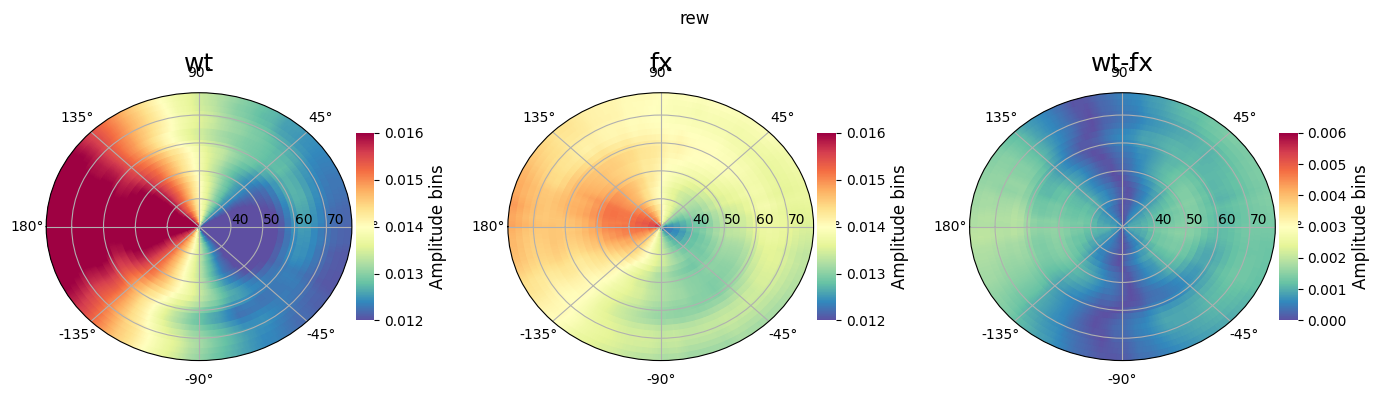

In [19]:
plt.rcdefaults()

plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_rew_wt, vb_rew_wt, po_rew_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_rew_fx, vb_rew_fx, po_rew_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(rew_diff, vb_rew_wt, po_rew_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('rew')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\rew_PAC_radial.pdf", transparent=True)

plt.show()

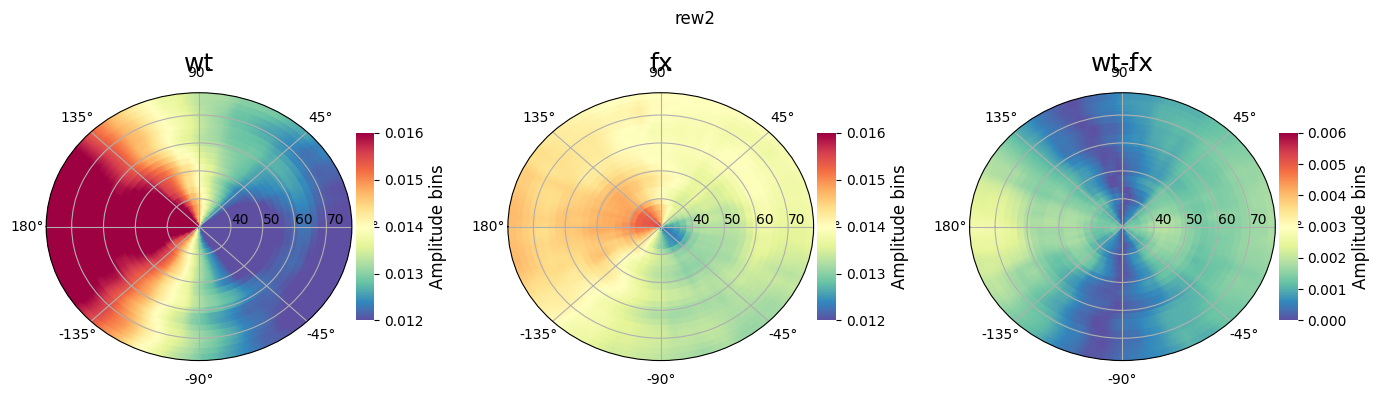

In [20]:
plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_rew2_wt, vb_rew2_wt, po_rew2_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_rew2_fx, vb_rew2_fx, po_rew2_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(rew2_diff, vb_rew2_wt, po_rew2_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('rew2')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\rew2_PAC_radial.pdf", transparent=True)

plt.show()

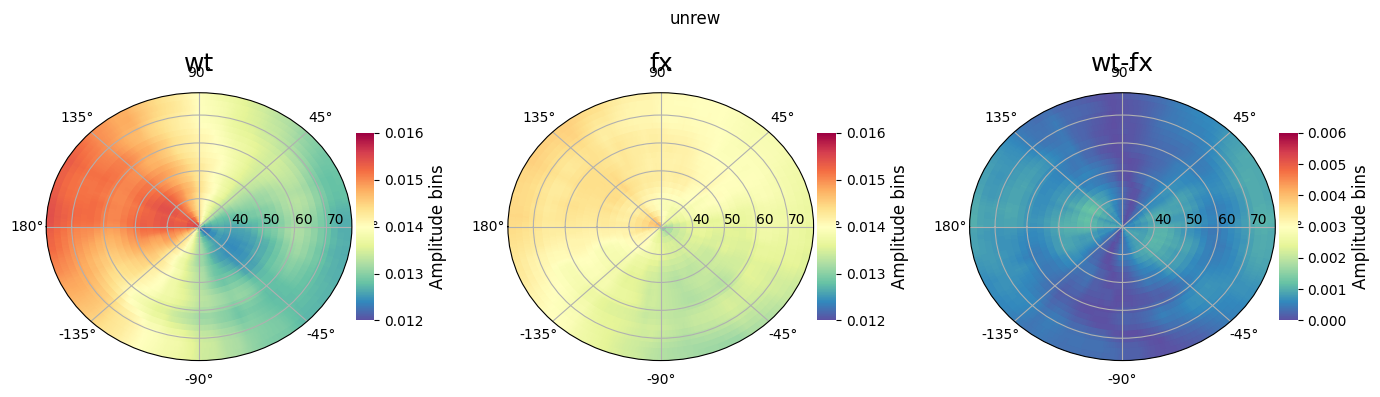

In [21]:
plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_unrew_wt, vb_unrew_wt, po_unrew_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_unrew_fx, vb_unrew_fx, po_unrew_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(unrew_diff, vb_unrew_wt, po_unrew_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('unrew')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\unrew_PAC_radial.pdf", transparent=True)

plt.show()

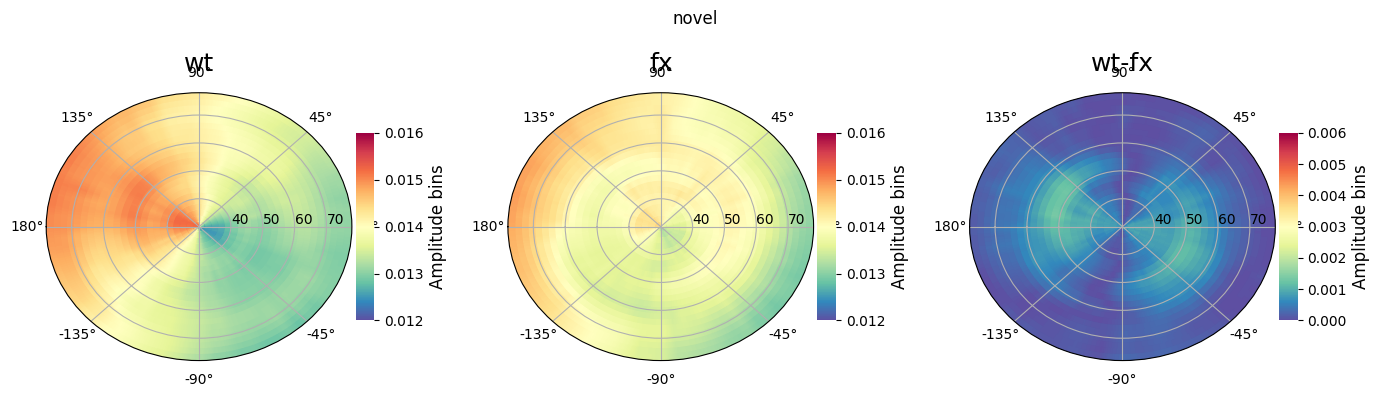

In [22]:
plt.figure(figsize=(14, 4))
pp_obj.polar(pp2_novel_wt, vb_novel_wt, po_novel_wt.yvec, subplot=131, title='wt', **kw_plt9)
pp_obj.polar(pp2_novel_fx, vb_novel_fx, po_novel_fx.yvec, subplot=132, title='fx', **kw_plt9)
pp_obj.polar(novel_diff, vb_novel_wt, po_novel_wt.yvec, subplot=133, title='wt-fx', **kw_plt99)
plt.suptitle('novel')
plt.tight_layout()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\PAC\novel_PAC_radial.pdf", transparent=True)

plt.show()

# Test if the theta-gamma PAC is significant during mid
finally, here, we are going to test if the peak PAC that is occurring during the mid period is significantly different for a surrogate distribution. To this end, and as recommended by Aru et al. 2015, the surrogate distribution is obtained by cutting an amplitude at a random time-point and then swap the two blocks of amplitudes (Bahramisharif et al. 2013). This procedure is then repeated multiple times (e.g 200 or 1000 times) in order to obtained the distribution. Finally, the p-value is inferred by computing the proportion exceeded by the true coupling. In addition, the correction for multiple comparison is obtained using the FDR.



In [ ]:
# still using the Gaussian-Copula PAC but this time, we also select the method for computing the permutations
p_obj.idpac = (6, 2, 0)
# compute pac and 200 surrogates
pac_mid = p_obj.fit(pha_p[..., time_2], amp_p[..., time_2], n_perm=1000,
                     random_state=0)
# get the p-values
mcp = 'maxstat'
pvalues = p_obj.infer_pvalues(p=0.05, mcp=mcp)

In [ ]:
# sphinx_gallery_thumbnail_number = 7
plt.figure(figsize=(8, 6))
title = (r"Significant theta$\Leftrightarrow$gamma coupling occurring during "
         f"the oscillation\n(p<0.05, {mcp}-corrected for multiple comparisons)")
# plot the non-significant pac in gray
pac_mid_ns = pac_mid.mean(-1).copy()
pac_mid_ns[pvalues < .05] = np.nan
p_obj.comodulogram(pac_mid_ns, cmap='gray', vmin=np.nanmin(pac_mid_ns),
                   vmax=np.nanmax(pac_mid_ns), colorbar=False)
# plot the significant pac in color
pac_mid_s = pac_mid.mean(-1).copy()
pac_mid_s[pvalues >= .05] = np.nan
p_obj.comodulogram(pac_mid_s, cmap='Spectral_r', vmin=np.nanmin(pac_mid_s),
                   vmax=np.nanmax(pac_mid_s), title=title)
plt.gca().invert_yaxis()
plt.show()